In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
import environment as environment_module
importlib.reload(environment_module)
from environment import Easy21, NNRecursiveWrapper
from empirical_dp import EmpiricalAlgorithms

env = Easy21()
solver = EmpiricalAlgorithms(env, alpha=0.95, n_samples=200, q_samples=200)

In [2]:
print("Running Empirical Value Iteration...")
v_evi, deltas_evi = solver.empirical_value_iteration(iterations=50)

Running Empirical Value Iteration...


In [3]:
print("Running Empirical Policy Iteration...")
v_epi, p_epi, deltas_epi = solver.empirical_policy_iteration(iterations=15)

Running Empirical Policy Iteration...


# True value function curves and algorithm implementation convergence

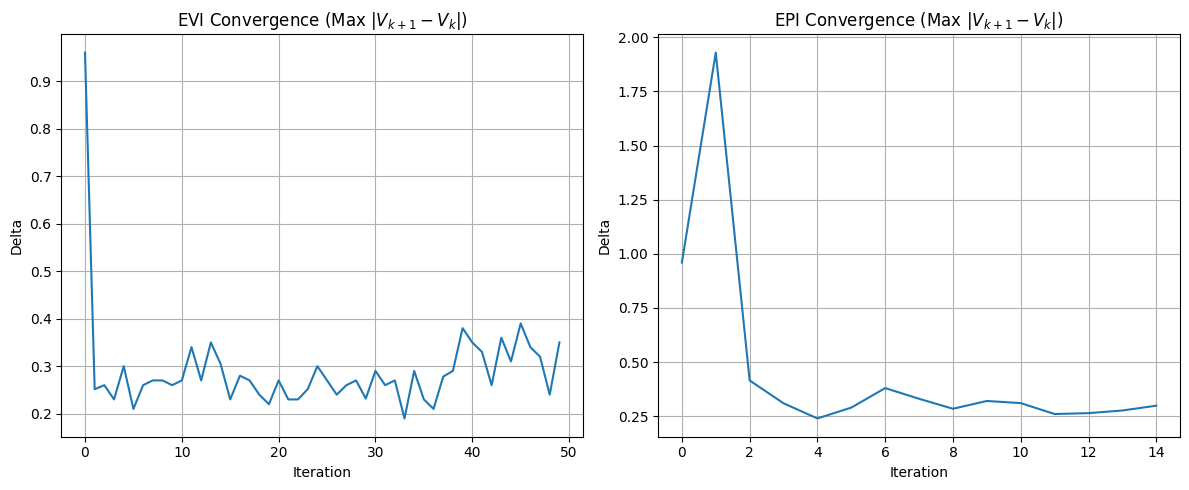

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(deltas_evi)
plt.title("EVI Convergence (Max $|V_{k+1} - V_k|$)")
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(deltas_epi)
plt.title("EPI Convergence (Max $|V_{k+1} - V_k|$)")
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.grid(True)

plt.tight_layout()
plt.show()

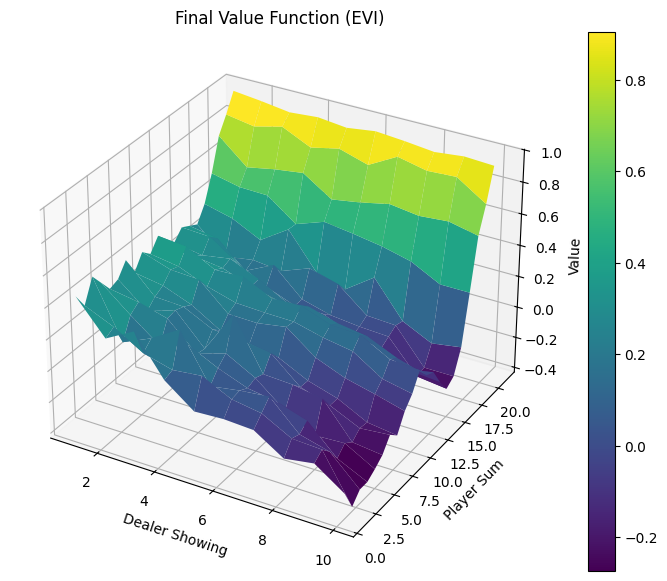

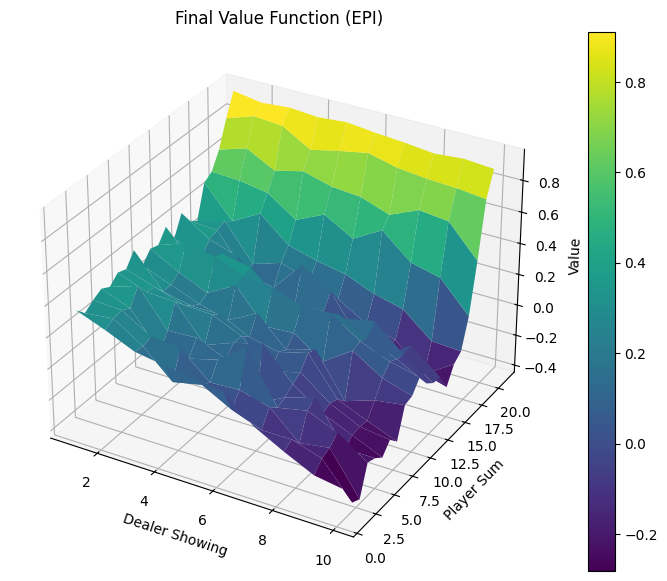

In [5]:
def plot_value_function(V, title):
    player_vals = np.arange(1, 22)
    dealer_vals = np.arange(1, 11)
    X, Y = np.meshgrid(dealer_vals, player_vals)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, V, cmap='viridis')

    ax.set_xlabel('Dealer Showing')
    ax.set_ylabel('Player Sum')
    ax.set_zlabel('Value')
    ax.set_title(title)
    plt.colorbar(surf)
    plt.show()

plot_value_function(v_evi, "Final Value Function (EVI)")
plot_value_function(v_epi, "Final Value Function (EPI)")

In [6]:
def pretrain_NN(a, b):
    wrapper = NNRecursiveWrapper(Easy21(), a, b, buffer_size=42000)
    for _ in range(5000):
        wrapper.begin_next_buffer()
        p, d = wrapper.env.initGame()
        wrapper.step(p, d, np.random.randint(0, 2))
        wrapper.commit_next_buffer()

    loss_history = wrapper.train_model(epochs=500)
    return wrapper, loss_history

In [7]:
def plot_loss_history(losses, title):
    plt.figure(figsize=(10, 4))
    plt.plot(losses, color='crimson', linewidth=2)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Average training loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [8]:
def run_evi_collapse(rec_env=None, iterations=40):
    solver = EmpiricalAlgorithms(rec_env, n_samples=100)
    v_final, deltas = solver.empirical_value_iteration(iterations=iterations)

    return v_final, deltas

def run_epi_collapse(rec_env=None, iterations=10):
    solver = EmpiricalAlgorithms(rec_env, n_samples=50, q_samples=50)
    v_final, policy, deltas = solver.empirical_policy_iteration(iterations=iterations)

    return v_final, deltas, policy

# Modified environment runs

- a = 1
- a = 0, b = 0.5

for both EVI and EPI

In [9]:
print("Analyzing EVI Collapse...")
wrapper1, loss_real = pretrain_NN(a=1.0, b=0.5)  # Pretrain with stable setting
# print("Pretrain Losses (Stable Setting):")
# plot_loss_history(loss_real, "Pretrain Loss History (Stable Setting)")
v_evi_stable, d_evi_stable = run_evi_collapse(wrapper1)
wrapper2, loss_collapse = pretrain_NN(a=0.0, b=0.5)  # Pretrain with collapse setting
# print("Pretrain Losses (Collapse Setting):")
# plot_loss_history(loss_collapse, "Pretrain Loss History (Collapse Setting)")
v_evi_collapse, d_evi_collapse = run_evi_collapse(wrapper2)

print("Analyzing EPI Collapse...")
wrapper3, loss_epi_stable = pretrain_NN(a=1.0, b=0.5)  # Pretrain with stable setting
# print("Pretrain Losses (Stable Setting):")
# plot_loss_history(loss_epi_stable, "Pretrain Loss History (Stable Setting)")
v_epi_stable, d_epi_stable, policy_epi_stable = run_epi_collapse(wrapper3)
wrapper4, loss_epi_collapse = pretrain_NN(a=0.0, b=0.5)  # Pretrain with collapse setting
# print("Pretrain Losses (Collapse Setting):")
# plot_loss_history(loss_epi_collapse, "Pretrain Loss History (Collapse Setting)")
v_epi_collapse, d_epi_collapse, policy_epi_collapse = run_epi_collapse(wrapper4)

Analyzing EVI Collapse...
Analyzing EPI Collapse...


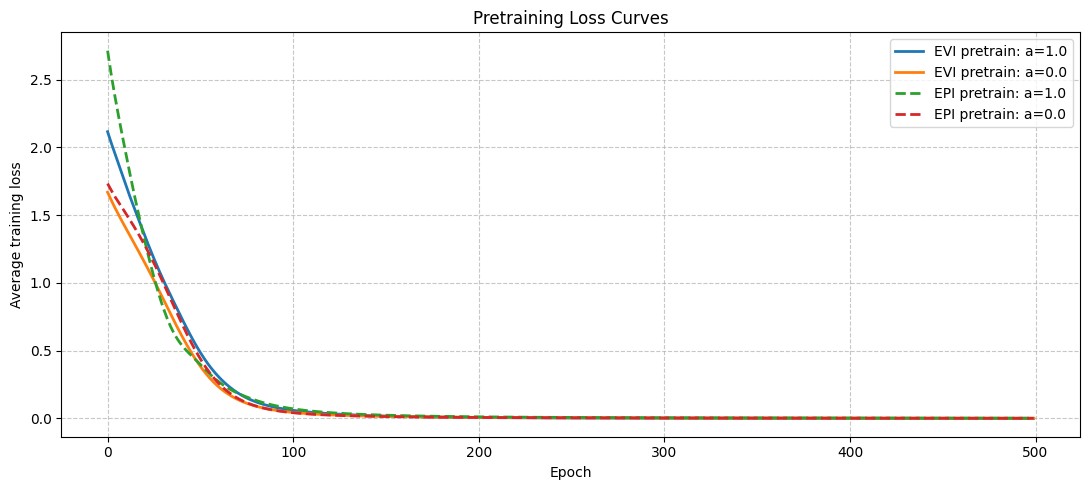

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(loss_real, label='EVI pretrain: a=1.0', linewidth=2)
ax.plot(loss_collapse, label='EVI pretrain: a=0.0', linewidth=2)
ax.plot(loss_epi_stable, label='EPI pretrain: a=1.0', linewidth=2, linestyle='--')
ax.plot(loss_epi_collapse, label='EPI pretrain: a=0.0', linewidth=2, linestyle='--')
ax.set_title('Pretraining Loss Curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('Average training loss')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
def plot_surface_ax(ax, V):
    player_range = np.arange(1, 22)
    dealer_range = np.arange(1, 11)

    D, P = np.meshgrid(dealer_range, player_range)

    surf = ax.plot_surface(D, P, V, cmap='coolwarm',
                           edgecolor='none', antialiased=True)

    ax.set_xlabel('Dealer Showing')
    ax.set_ylabel('Player Sum')
    ax.set_zlabel('Value')

    ax.view_init(elev=30, azim=-135)

    return surf

In [12]:
def plot_policy_heatmap(policy, title="EPI Policy Heatmap"):
    if policy.shape != (21, 10):
        raise ValueError(f"Expected policy shape (21, 10), got {policy.shape}")

    cmap = ListedColormap(["#1f77b4", "#ff7f0e"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(
        policy,
        cmap=cmap,
        norm=norm,
        origin="lower",
        aspect="auto",
        extent=[1, 10, 1, 21],
    )

    ax.set_title(title)
    ax.set_xlabel("Dealer Showing")
    ax.set_ylabel("Player Sum")
    ax.set_xticks(np.arange(1, 11))
    ax.set_yticks(np.arange(1, 22))
    ax.grid(color="white", linestyle="-", linewidth=0.35, alpha=0.35)

    legend_handles = [
        Patch(facecolor="#1f77b4", label="0: Hit"),
        Patch(facecolor="#ff7f0e", label="1: Stick"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()

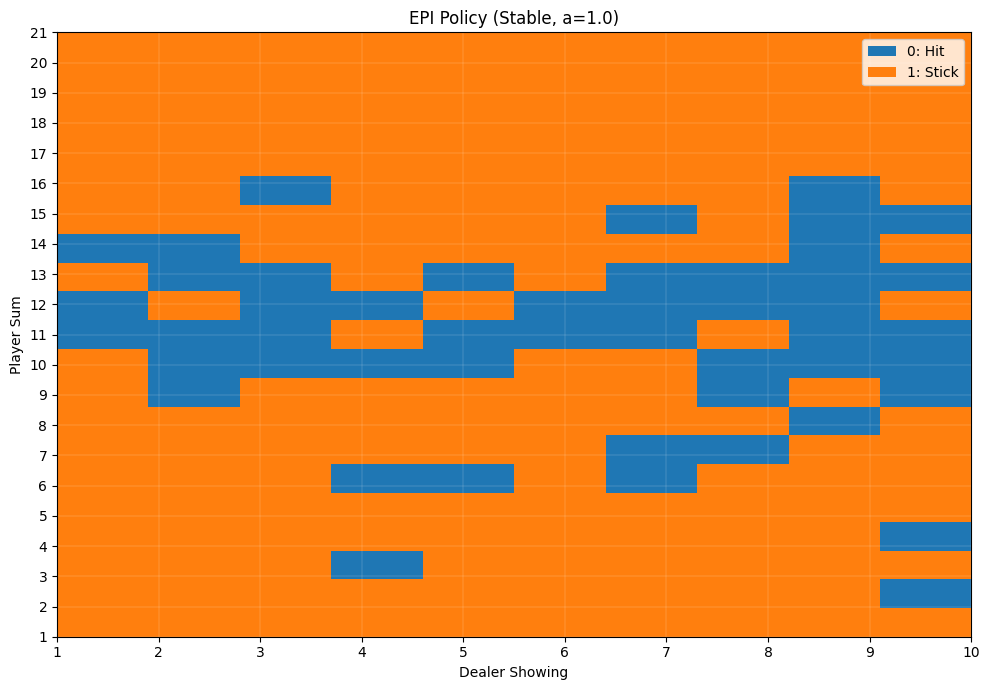

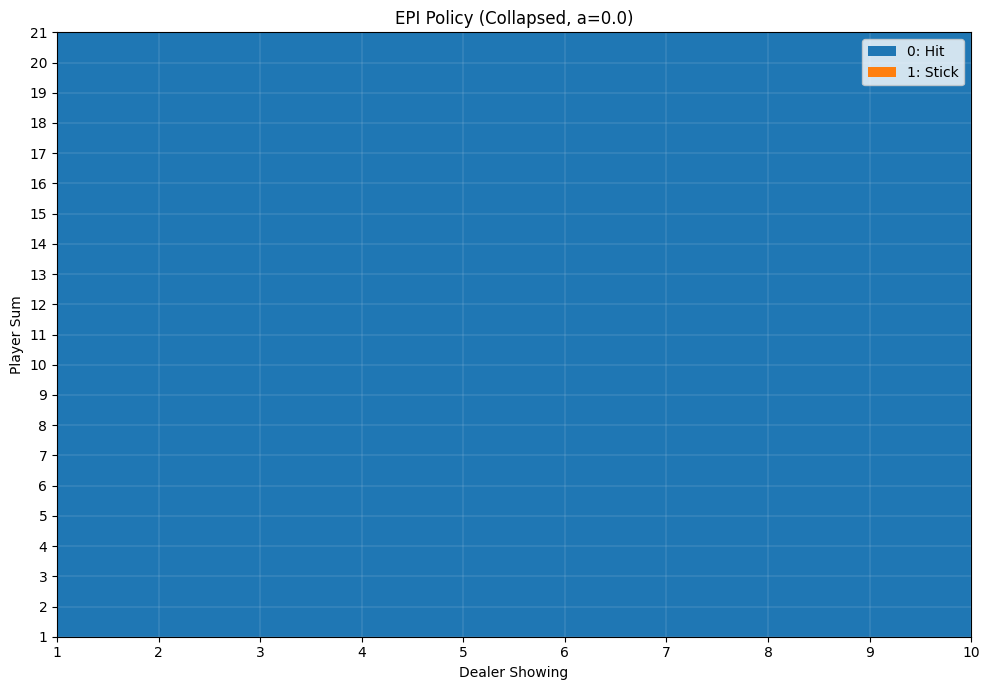

In [13]:
plot_policy_heatmap(policy_epi_stable, "EPI Policy (Stable, a=1.0)")
plot_policy_heatmap(policy_epi_collapse, "EPI Policy (Collapsed, a=0.0)")

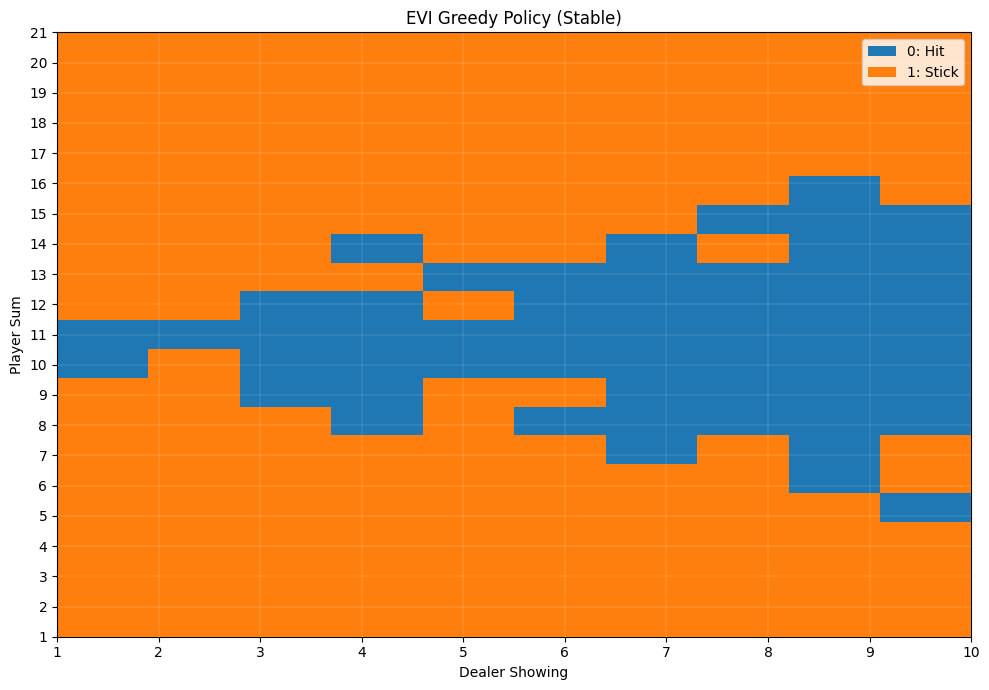

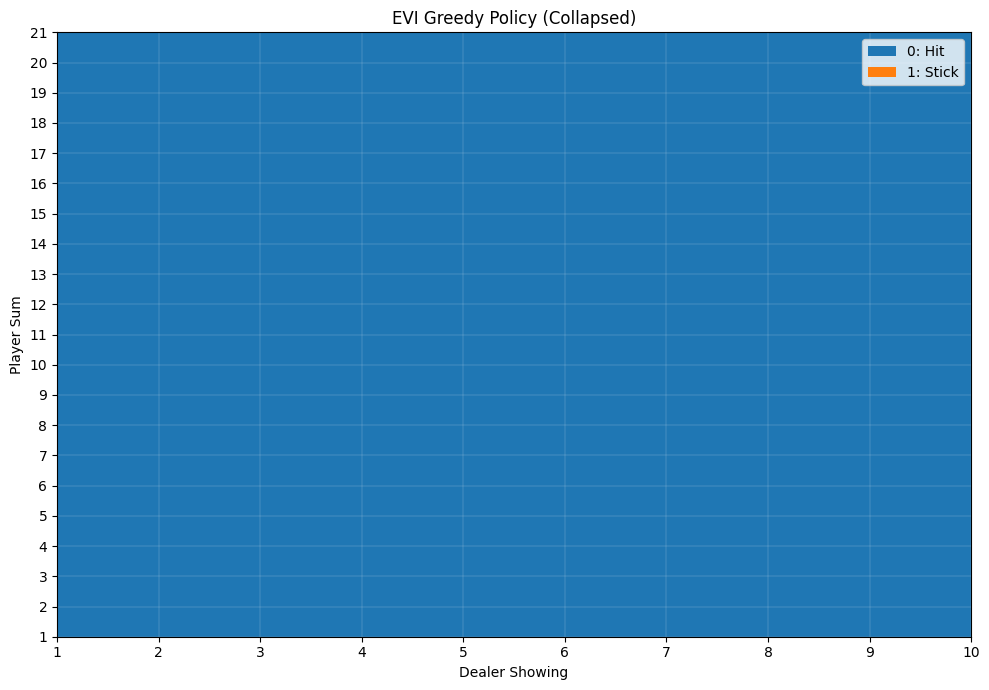

In [14]:
def compute_greedy_policy_from_value(V, env, gamma=0.95, n_samples=200):
    # V expected shape (21, 10) with indices [player-1, dealer-1]
    policy = np.zeros((21, 10), dtype=int)
    for p in range(1, 22):
        for d in range(1, 11):
            q_vals = []
            for a in [0, 1]:
                samples = []
                for _ in range(n_samples):
                    p_n, d_n, r, term = env.step(p, d, int(a))
                    if term:
                        val_next = 0.0
                    else:
                        val_next = V[p_n - 1, d_n - 1]
                    samples.append(r + gamma * val_next)
                q_vals.append(float(np.mean(samples)))
            policy[p - 1, d - 1] = int(np.argmax(q_vals))
    return policy

# Compute and plot greedy policies derived from EVI value functions
policy_evi_stable = compute_greedy_policy_from_value(v_evi_stable, wrapper1 if 'wrapper1' in globals() else env, gamma=0.95, n_samples=200)
policy_evi_collapse = compute_greedy_policy_from_value(v_evi_collapse, wrapper2 if 'wrapper2' in globals() else env, gamma=0.95, n_samples=200)

plot_policy_heatmap(policy_evi_stable, "EVI Greedy Policy (Stable)")
plot_policy_heatmap(policy_evi_collapse, "EVI Greedy Policy (Collapsed)")

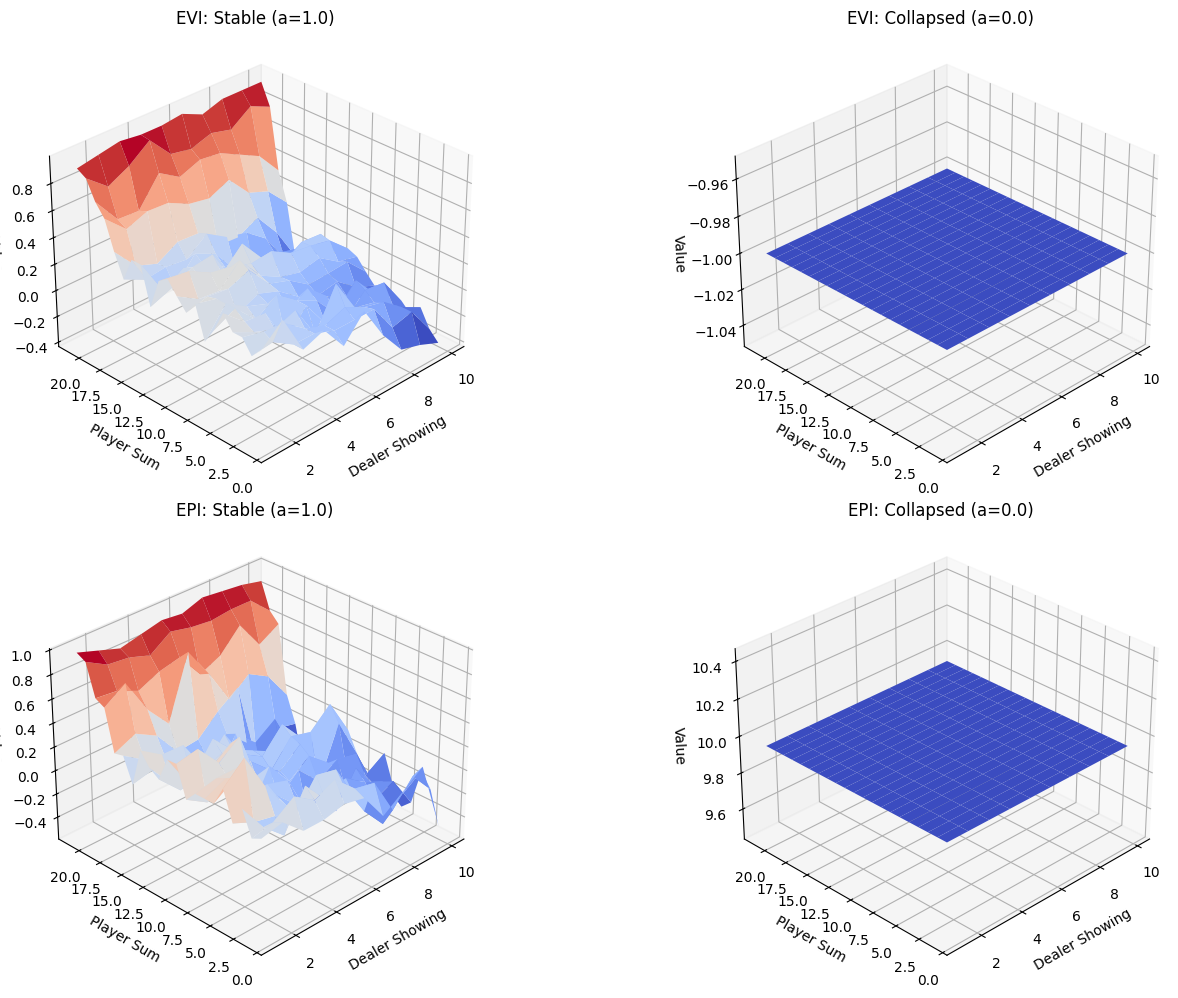

In [15]:
fig = plt.figure(figsize=(16, 10))

# --- EVI Plots ---
ax1 = fig.add_subplot(221, projection='3d')
ax1.set_title("EVI: Stable (a=1.0)")
plot_surface_ax(ax1, v_evi_stable)

ax2 = fig.add_subplot(222, projection='3d')
ax2.set_title("EVI: Collapsed (a=0.0)")
plot_surface_ax(ax2, v_evi_collapse)

# --- EPI Plots ---
ax3 = fig.add_subplot(223, projection='3d')
ax3.set_title("EPI: Stable (a=1.0)")
plot_surface_ax(ax3, v_epi_stable)

ax4 = fig.add_subplot(224, projection='3d')
ax4.set_title("EPI: Collapsed (a=0.0)")
plot_surface_ax(ax4, v_epi_collapse)

plt.tight_layout()
plt.show()